# Lesion-Based (Calcification, Mass) Training Experiments for all CNNs

**Image Preprocessing Pipeline:** CLAHE + Median Blur (from image preprocessing experiment results)

**Image View:** CC-Only-View (from view-specific training experiment results)

* VGG16
* ResNet50
* DenseNet121
* MobileNetV2
* EfficientNet-B0

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121, MobileNetV2, EfficientNetB0
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 756, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 756 (delta 23), reused 51 (delta 18), pack-reused 693 (from 2)
Receiving objects: 100% (756/756), 24.26 MiB | 26.66 MiB/s, done.
Resolving deltas: 100% (366/366), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.dataset import generate_class_weight_dict
from src.workflows.dataset_generation import *
from src.workflows.training_and_evaluation import *
from src.common_model_functions import *
from src.experimental_results_functions import generate_lesion_results_metrics_df, store_experiment_results
from src.visualizations import *
from src.constants import BATCH_SIZE, CLASSES, CLASSIFICATION_THRESHOLD, EXPERIMENTAL_EPOCHS

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training and validation datasets (containing images) and store them in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training and validation metadata CSV files from drive and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)

In [ ]:
# Calcification-only lesion with CC-Only view
train_df_c = train_df.loc[(train_df['abnormality type'] == 'calcification') & (train_df['image view'] == 'CC')]
val_df_c = val_df.loc[(val_df['abnormality type'] == 'calcification') & (val_df['image view'] == 'CC')]

In [ ]:
# Class distributions for Calcification
print(train_df_c['pathology'].value_counts())
print(val_df_c['pathology'].value_counts())

pathology
0.0    360
1.0    187
Name: count, dtype: int64
pathology
0.0    106
1.0     48
Name: count, dtype: int64


In [ ]:
# Mass-only lesion with CC-Only view
train_df_m = train_df.loc[(train_df['abnormality type'] == 'mass') & (train_df['image view'] == 'CC')]
val_df_m = val_df.loc[(val_df['abnormality type'] == 'mass') & (val_df['image view'] == 'CC')]

In [ ]:
# Class distributions for Mass
print(train_df_m['pathology'].value_counts())
print(val_df_m['pathology'].value_counts())

pathology
0.0    280
1.0    236
Name: count, dtype: int64
pathology
0.0    62
1.0    58
Name: count, dtype: int64


In [ ]:
# Validation set true labels for evaluation
val_true_labels_c = val_df_c['pathology'].to_numpy()
val_true_labels_m = val_df_m['pathology'].to_numpy()

In [ ]:
# CSV Files to store all experimental results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Experiment_Results/lesions_experiment_results.csv"

In [ ]:
# Buffer size for shuffling in training dataset
BUFFER_SIZE_C = len(train_df_c)
BUFFER_SIZE_M = len(train_df_m)
# No. of training samples in Calcification and Mass dataframes for class weight
TOTAL_TRAINING_SAMPLES_C = len(train_df_c)
TOTAL_TRAINING_SAMPLES_M = len(train_df_m)

In [ ]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# Class-Imbalance Handling
class_weights_dict_c = generate_class_weight_dict(train_df_c, CLASSES, TOTAL_TRAINING_SAMPLES_C)
class_weights_dict_m = generate_class_weight_dict(train_df_m, CLASSES, TOTAL_TRAINING_SAMPLES_M)

In [ ]:
# Image preprocessor
clahe_median_blur_preprocessor = IMAGE_PREPROCESSORS['clahe_median_blur']

## Calcification lesion only Experiment (with CC-Only-View and CLAHE + Median Blur Preprocessor)

#### tf.data Datasets for Calcification-Only Lesion

In [ ]:
# Generate training and validation datasets for Calcification only
train_dataset_c = dataset_preparation(train_df_c, clahe_median_blur_preprocessor, BUFFER_SIZE_C, BATCH_SIZE, training=True)
val_dataset_c = dataset_preparation(val_df_c, clahe_median_blur_preprocessor, BUFFER_SIZE_C, BATCH_SIZE, training=False)

### VGG16

In [ ]:
# Select the VGG16 model
vgg16_model_c = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_c, train_time_vgg16_c, peak_memory_vgg16_c = train_selected_model(vgg16_model_c,
                                                                        train_dataset_c,
                                                                        val_dataset_c,
                                                                        EXPERIMENTAL_EPOCHS,
                                                                        early_stopping,
                                                                        class_weights_dict_c)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 560ms/step - auc: 0.3161 - loss: 1.3454 - precision: 0.3154 - recall: 0.5027 - val_auc: 0.2745 - val_loss: 0.9208 - val_precision: 0.2667 - val_recall: 0.2500
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 518ms/step - auc: 0.3604 - loss: 0.9974 - precision: 0.3589 - recall: 0.4011 - val_auc: 0.3527 - val_loss: 0.7460 - val_precision: 0.4255 - val_recall: 0.4167
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 531ms/step - auc: 0.4049 - loss: 0.8897 - precision: 0.4322 - recall: 0.4599 - val_auc: 0.4270 - val_loss: 0.7391 - val_precision: 0.4179 - val_recall: 0.5833
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 514ms/step - auc: 0.3904 - loss: 0.8348 - precision: 0.4059 - recall: 0.5187 - val_auc: 0.4241 - val_loss: 0.6750 - val_precision: 0.4333 - val_recall: 0.5417
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 517ms/step - auc: 0.4544 - loss: 0.7699 - precision: 0.4910 - recall: 0.4385 - val_auc: 0.4387 - val_lo

In [ ]:
# Predictions and evaluations using the trained VGG16 model
_, preds_vgg16_c, metrics_dict_vgg16_c, infer_time_vgg16_c = generate_predictions_and_evaluations(vgg16_c, val_dataset_c, val_true_labels_c, CLASSIFICATION_THRESHOLD)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step - auc: 0.4684 - loss: 0.5718 - precision: 0.5476 - recall: 0.4792


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_c_results_df = generate_lesion_results_metrics_df(
    model_name='VGG16',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_vgg16_c,
    train_time=train_time_vgg16_c,
    infer_time=infer_time_vgg16_c,
    peak_memory=peak_memory_vgg16_c,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_c_results_df)

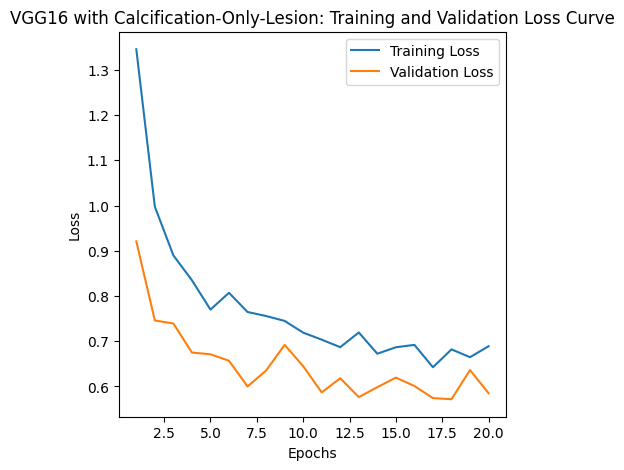

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_c.history, 'VGG16', 'Calcification-Only-Lesion')

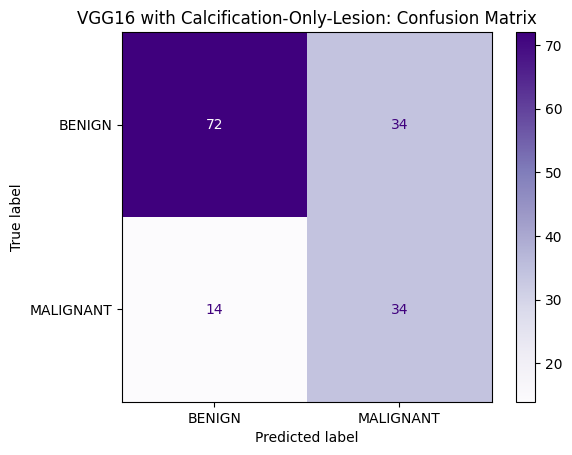

In [ ]:
plot_confusion_matrix(val_true_labels_c, preds_vgg16_c, 'VGG16', 'Calcification-Only-Lesion')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_c = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_c, train_time_resnet50_c, peak_memory_resnet50_c = train_selected_model(resnet50_model_c,
                                                                                 train_dataset_c,
                                                                                 val_dataset_c,
                                                                                 EXPERIMENTAL_EPOCHS,
                                                                                 early_stopping,
                                                                                 class_weights_dict_c)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 729ms/step - auc: 0.3802 - loss: 0.7352 - precision: 0.4000 - recall: 0.3209 - val_auc: 0.5090 - val_loss: 0.5235 - val_precision: 0.6364 - val_recall: 0.2917
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 528ms/step - auc: 0.4807 - loss: 0.6484 - precision: 0.5080 - recall: 0.5080 - val_auc: 0.5445 - val_loss: 0.5211 - val_precision: 0.5862 - val_recall: 0.3542
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 536ms/step - auc: 0.4728 - loss: 0.6386 - precision: 0.5098 - recall: 0.4171 - val_auc: 0.5672 - val_loss: 0.5756 - val_precision: 0.5636 - val_recall: 0.6458
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 578ms/step - auc: 0.5165 - loss: 0.5961 - precision: 0.5449 - recall: 0.5187 - val_auc: 0.5485 - val_loss: 0.5796 - val_precision: 0.5098 - val_recall: 0.5417
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 468ms/step - auc: 0.5520 - loss: 0.5883 - precision: 0.5632 - recall: 0.5722 - val_auc: 0.5370 - val_lo

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
_, preds_resnet50_c, metrics_dict_resnet50_c, infer_time_resnet50_c = generate_predictions_and_evaluations(resnet50_c, val_dataset_c, val_true_labels_c,
                                                                                                         CLASSIFICATION_THRESHOLD)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 635ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - auc: 0.5905 - loss: 0.5176 - precision: 0.6667 - recall: 0.3333


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_c_results_df = generate_lesion_results_metrics_df(
    model_name='ResNet50',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_resnet50_c,
    train_time=train_time_resnet50_c,
    infer_time=infer_time_resnet50_c,
    peak_memory=peak_memory_resnet50_c,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_c_results_df)

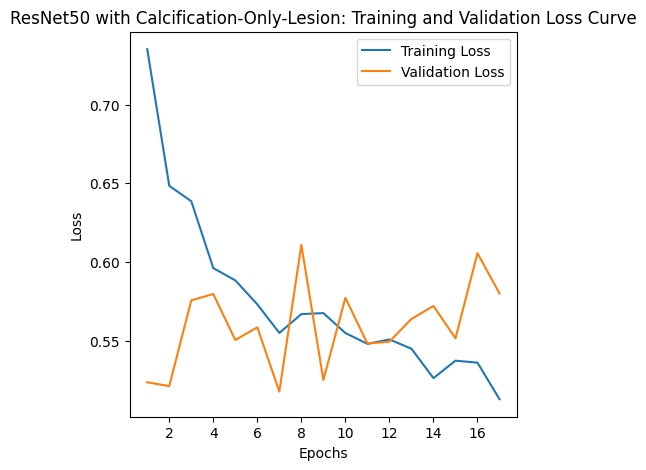

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_c.history, 'ResNet50', 'Calcification-Only-Lesion')

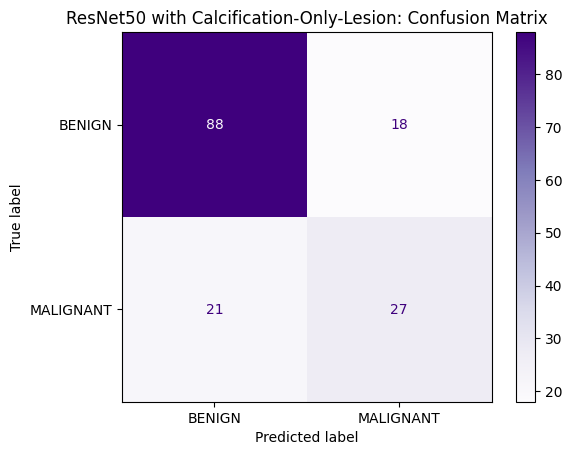

In [ ]:
plot_confusion_matrix(val_true_labels_c, preds_resnet50_c, 'ResNet50', 'Calcification-Only-Lesion')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_c = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_c, train_time_densenet121_c, peak_memory_densenet121_c = train_selected_model(densenet121_model_c,
                                                                                          train_dataset_c,
                                                                                          val_dataset_c,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict_c)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 825ms/step - auc: 0.3789 - loss: 1.1856 - precision: 0.3955 - recall: 0.4652 - val_auc: 0.3840 - val_loss: 0.6821 - val_precision: 0.4375 - val_recall: 0.1458
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 542ms/step - auc: 0.3830 - loss: 1.1989 - precision: 0.3846 - recall: 0.4545 - val_auc: 0.4394 - val_loss: 0.6806 - val_precision: 0.5385 - val_recall: 0.2917
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 545ms/step - auc: 0.3880 - loss: 1.1817 - precision: 0.4050 - recall: 0.5241 - val_auc: 0.4274 - val_loss: 0.6241 - val_precision: 0.6000 - val_recall: 0.1875
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 523ms/step - auc: 0.4188 - loss: 0.9856 - precision: 0.4485 - recall: 0.3957 - val_auc: 0.4686 - val_loss: 0.7300 - val_precision: 0.5098 - val_recall: 0.5417
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 496ms/step - auc: 0.4281 - loss: 0.9075 - precision: 0.4420 - recall: 0.4278 - val_auc: 0.4568 - val_lo

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
_, preds_densenet121_c, metrics_dict_densenet121_c, infer_time_densenet121_c = generate_predictions_and_evaluations(densenet121_c, val_dataset_c, val_true_labels_c,
                                                                                                                    CLASSIFICATION_THRESHOLD)

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - auc: 0.4551 - loss: 0.5660 - precision: 0.5909 - recall: 0.2708


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_c_results_df = generate_lesion_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_densenet121_c,
    train_time=train_time_densenet121_c,
    infer_time=infer_time_densenet121_c,
    peak_memory=peak_memory_densenet121_c,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_c_results_df)

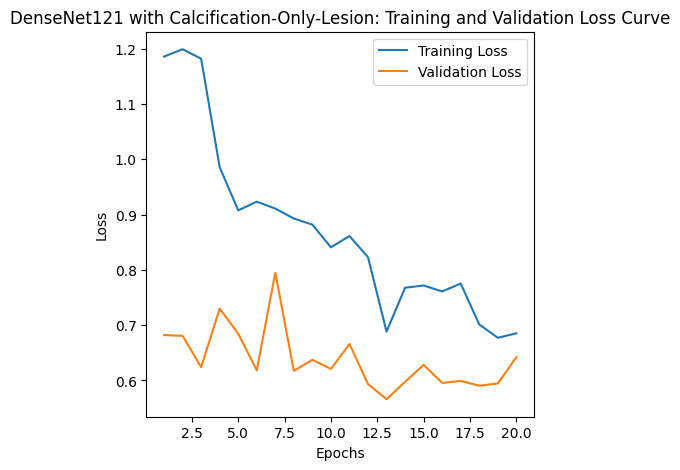

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_c.history, 'DenseNet121', 'Calcification-Only-Lesion')

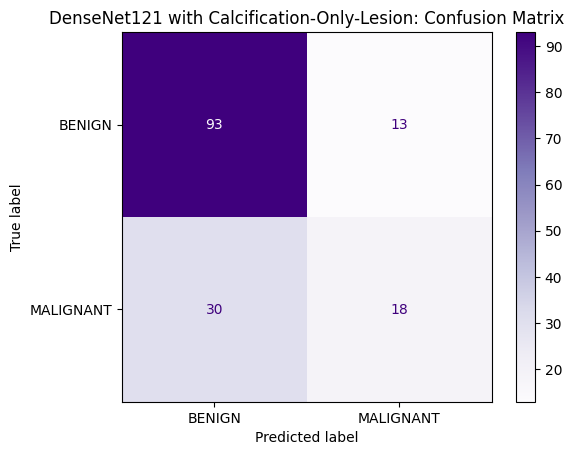

In [ ]:
plot_confusion_matrix(val_true_labels_c, preds_densenet121_c, 'DenseNet121', 'Calcification-Only-Lesion')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_c = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_c, train_time_mobilenetv2_c, peak_memory_mobilenetv2_c = train_selected_model(mobilenetv2_model_c,
                                                                                          train_dataset_c,
                                                                                          val_dataset_c,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict_c)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 641ms/step - auc: 0.3902 - loss: 0.7052 - precision: 0.4630 - recall: 0.2674 - val_auc: 0.5057 - val_loss: 0.6996 - val_precision: 0.5000 - val_recall: 0.3333
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 418ms/step - auc: 0.4615 - loss: 0.6704 - precision: 0.5217 - recall: 0.3209 - val_auc: 0.4877 - val_loss: 0.6792 - val_precision: 0.4595 - val_recall: 0.3542
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 493ms/step - auc: 0.4643 - loss: 0.6651 - precision: 0.5074 - recall: 0.3690 - val_auc: 0.4380 - val_loss: 0.7351 - val_precision: 0.4423 - val_recall: 0.4792
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 498ms/step - auc: 0.4719 - loss: 0.6635 - precision: 0.4881 - recall: 0.4385 - val_auc: 0.5043 - val_loss: 0.6589 - val_precision: 0.4706 - val_recall: 0.3333
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 490ms/step - auc: 0.4658 - loss: 0.6598 - precision: 0.5086 - recall: 0.3155 - val_auc: 0.4290 - val_loss

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
_, preds_mobilenetv2_c, metrics_dict_mobilenetv2_c, infer_time_mobilenetv2_c = generate_predictions_and_evaluations(mobilenetv2_c, val_dataset_c, val_true_labels_c,
                                                                                                                    CLASSIFICATION_THRESHOLD)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 486ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - auc: 0.4755 - loss: 0.6260 - precision: 0.4615 - recall: 0.2500


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_c_results_df = generate_lesion_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_mobilenetv2_c,
    train_time=train_time_mobilenetv2_c,
    infer_time=infer_time_mobilenetv2_c,
    peak_memory=peak_memory_mobilenetv2_c,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_c_results_df)

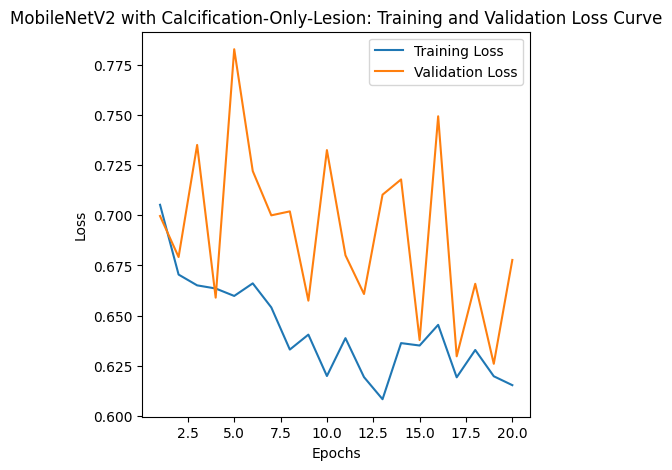

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_c.history, 'MobileNetV2', 'Calcification-Only-Lesion')

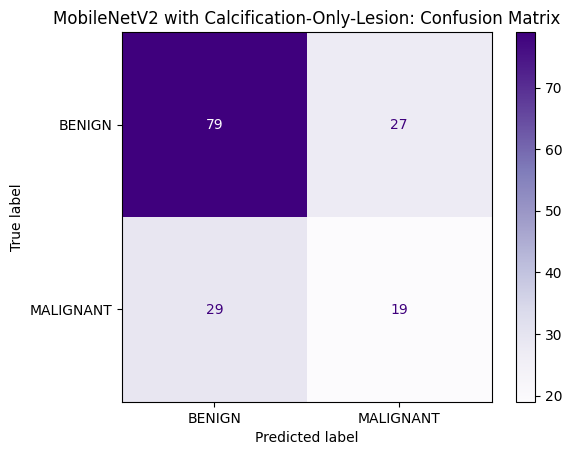

In [ ]:
plot_confusion_matrix(val_true_labels_c, preds_mobilenetv2_c, 'MobileNetV2', 'Calcification-Only-Lesion')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_c = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_c, train_time_efficientnetb0_c, peak_memory_efficientnetb0_c = train_selected_model(efficientnetb0_model_c,
                                                                                                   train_dataset_c,
                                                                                                   val_dataset_c,
                                                                                                   EXPERIMENTAL_EPOCHS,
                                                                                                   early_stopping,
                                                                                                   class_weights_dict_c)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 30s 679ms/step - auc: 0.3697 - loss: 0.7125 - precision: 0.4500 - recall: 0.0963 - val_auc: 0.4868 - val_loss: 0.6767 - val_precision: 0.5263 - val_recall: 0.2083
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 500ms/step - auc: 0.4538 - loss: 0.6393 - precision: 0.5102 - recall: 0.2674 - val_auc: 0.5617 - val_loss: 0.6026 - val_precision: 0.5938 - val_recall: 0.3958
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 436ms/step - auc: 0.5397 - loss: 0.6099 - precision: 0.5776 - recall: 0.3583 - val_auc: 0.5596 - val_loss: 0.5892 - val_precision: 0.5714 - val_recall: 0.5000
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 447ms/step - auc: 0.5135 - loss: 0.6046 - precision: 0.5549 - recall: 0.4866 - val_auc: 0.5468 - val_loss: 0.5625 - val_precision: 0.6364 - val_recall: 0.2917
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 498ms/step - auc: 0.5737 - loss: 0.5876 - precision: 0.6375 - recall: 0.2727 - val_auc: 0.5742 - val_lo

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
_, preds_efficientnetb0_c, metrics_dict_efficientnetb0_c, infer_time_efficientnetb0_c = generate_predictions_and_evaluations(efficientnetb0_c, val_dataset_c,
                                                                                                                             val_true_labels_c,
                                                                                                                             CLASSIFICATION_THRESHOLD)

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 899ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - auc: 0.5533 - loss: 0.5296 - precision: 0.5833 - recall: 0.4375


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_c_results_df = generate_lesion_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_efficientnetb0_c,
    train_time=train_time_efficientnetb0_c,
    infer_time=infer_time_efficientnetb0_c,
    peak_memory=peak_memory_efficientnetb0_c,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_c_results_df)

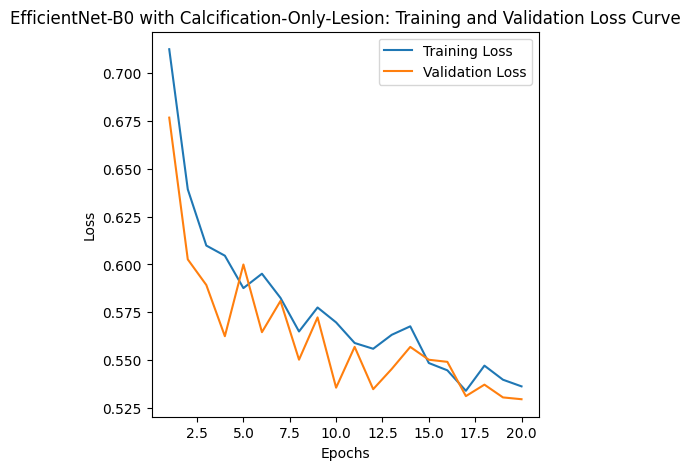

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_c.history, 'EfficientNet-B0', 'Calcification-Only-Lesion')

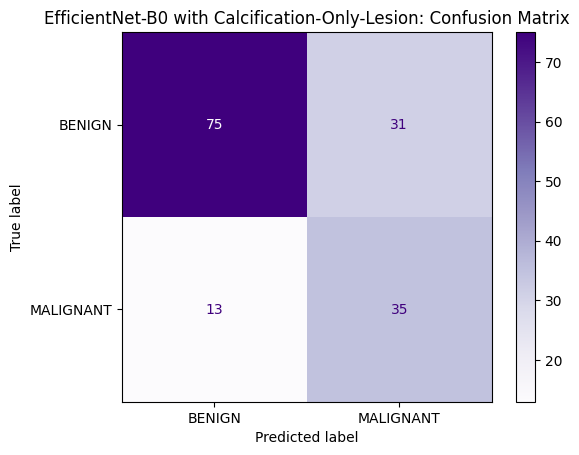

In [ ]:
plot_confusion_matrix(val_true_labels_c, preds_efficientnetb0_c, 'EfficientNet-B0', 'Calcification-Only-Lesion')

## Mass Lesion Only Experiment (with CC-Only-View and CLAHE + Median Blur Preprocessor)

#### tf.data Datasets for Mass-only Lesion

In [ ]:
# Generate training and validation datasets for Mass only
train_dataset_m = dataset_preparation(train_df_m, clahe_median_blur_preprocessor, BUFFER_SIZE_M, BATCH_SIZE, training=True)
val_dataset_m = dataset_preparation(val_df_m, clahe_median_blur_preprocessor, BUFFER_SIZE_M, BATCH_SIZE, training=False)

### VGG16

In [ ]:
# Select the VGG16 model
vgg16_model_m = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_m, train_time_vgg16_m, peak_memory_vgg16_m = train_selected_model(vgg16_model_m,
                                                                        train_dataset_m,
                                                                        val_dataset_m,
                                                                        EXPERIMENTAL_EPOCHS,
                                                                        early_stopping,
                                                                        class_weights_dict_m)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 598ms/step - auc: 0.4364 - loss: 1.0627 - precision: 0.4454 - recall: 0.4492 - val_auc: 0.5254 - val_loss: 0.6999 - val_precision: 0.5000 - val_recall: 0.1379
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 452ms/step - auc: 0.4840 - loss: 0.8423 - precision: 0.4652 - recall: 0.3686 - val_auc: 0.5466 - val_loss: 0.6750 - val_precision: 0.5789 - val_recall: 0.1897
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 483ms/step - auc: 0.4820 - loss: 0.8602 - precision: 0.5075 - recall: 0.4322 - val_auc: 0.5714 - val_loss: 0.6614 - val_precision: 0.6207 - val_recall: 0.3103
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 510ms/step - auc: 0.5098 - loss: 0.8459 - precision: 0.5381 - recall: 0.4492 - val_auc: 0.5882 - val_loss: 0.6568 - val_precision: 0.6538 - val_recall: 0.2931
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 473ms/step - auc: 0.5117 - loss: 0.8139 - precision: 0.5349 - recall: 0.3898 - val_auc: 0.6179 - val_los

In [ ]:
# Predictions and evaluations using the trained VGG16 model
_, preds_vgg16_m, metrics_dict_vgg16_m, infer_time_vgg16_m = generate_predictions_and_evaluations(vgg16_m, val_dataset_m, val_true_labels_m, CLASSIFICATION_THRESHOLD)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - auc: 0.6776 - loss: 0.6475 - precision: 0.6977 - recall: 0.5172


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_m_results_df = generate_lesion_results_metrics_df(
    model_name='VGG16',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_vgg16_m,
    train_time=train_time_vgg16_m,
    infer_time=infer_time_vgg16_m,
    peak_memory=peak_memory_vgg16_m,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_m_results_df)

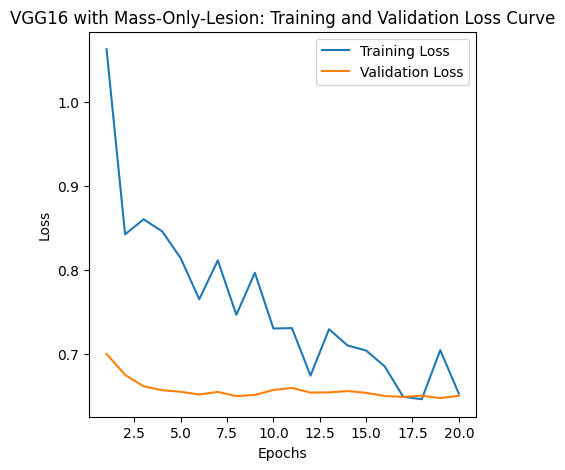

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_m.history, 'VGG16', 'Mass-Only-Lesion')

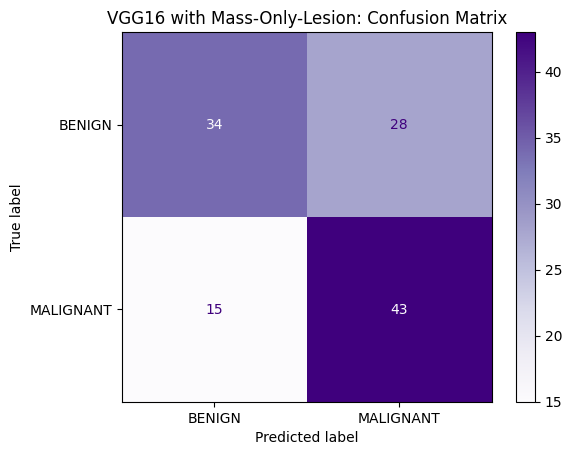

In [ ]:
plot_confusion_matrix(val_true_labels_m, preds_vgg16_m, 'VGG16', 'Mass-Only-Lesion')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_m = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_m, train_time_resnet50_m, peak_memory_resnet50_m = train_selected_model(resnet50_model_m,
                                                                                 train_dataset_m,
                                                                                 val_dataset_m,
                                                                                 EXPERIMENTAL_EPOCHS,
                                                                                 early_stopping,
                                                                                 class_weights_dict_m)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 26s 669ms/step - auc: 0.4793 - loss: 0.7453 - precision: 0.4967 - recall: 0.3220 - val_auc: 0.6859 - val_loss: 0.6534 - val_precision: 1.0000 - val_recall: 0.0345
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 462ms/step - auc: 0.5312 - loss: 0.7003 - precision: 0.5672 - recall: 0.3220 - val_auc: 0.6993 - val_loss: 0.6366 - val_precision: 0.7419 - val_recall: 0.3966
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 422ms/step - auc: 0.5884 - loss: 0.6549 - precision: 0.6444 - recall: 0.3686 - val_auc: 0.6860 - val_loss: 0.6369 - val_precision: 0.6970 - val_recall: 0.3966
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 502ms/step - auc: 0.5959 - loss: 0.6622 - precision: 0.6082 - recall: 0.4407 - val_auc: 0.7003 - val_loss: 0.6325 - val_precision: 0.6905 - val_recall: 0.5000
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 444ms/step - auc: 0.6081 - loss: 0.6720 - precision: 0.6589 - recall: 0.3602 - val_auc: 0.7049 - val_loss:

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
_, preds_resnet50_m, metrics_dict_resnet50_m, infer_time_resnet50_m = generate_predictions_and_evaluations(resnet50_m, val_dataset_m, val_true_labels_m,
                                                                                                           CLASSIFICATION_THRESHOLD)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 689ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - auc: 0.7729 - loss: 0.5917 - precision: 0.8293 - recall: 0.5862


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_m_results_df = generate_lesion_results_metrics_df(
    model_name='ResNet50',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_resnet50_m,
    train_time=train_time_resnet50_m,
    infer_time=infer_time_resnet50_m,
    peak_memory=peak_memory_resnet50_m,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_m_results_df)

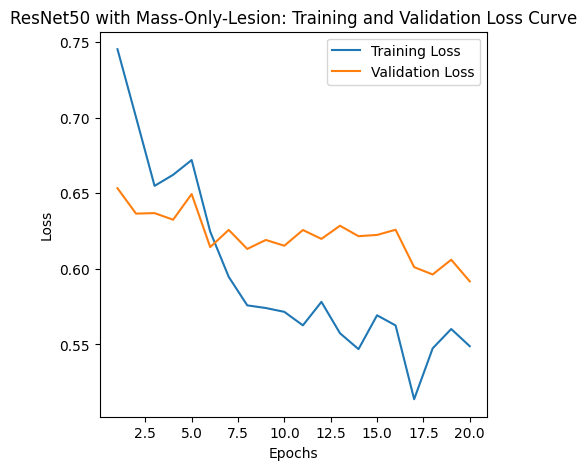

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_m.history, 'ResNet50', 'Mass-Only-Lesion')

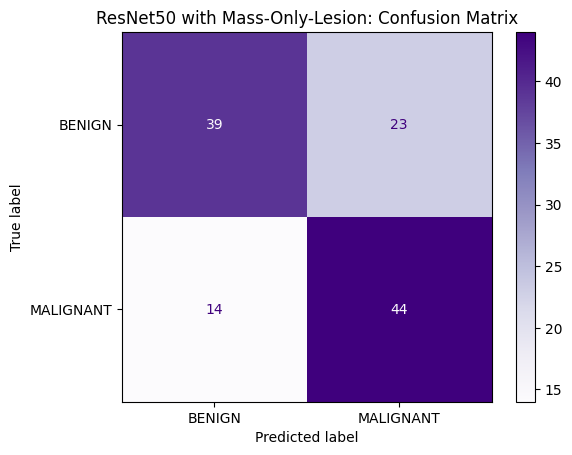

In [ ]:
plot_confusion_matrix(val_true_labels_m, preds_resnet50_m, 'ResNet50', 'Mass-Only-Lesion')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_m = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_m, train_time_densenet121_m, peak_memory_densenet121_m = train_selected_model(densenet121_model_m,
                                                                                          train_dataset_m,
                                                                                          val_dataset_m,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict_m)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 32s 775ms/step - auc: 0.4892 - loss: 1.3928 - precision: 0.4928 - recall: 0.4322 - val_auc: 0.5230 - val_loss: 0.8060 - val_precision: 0.6000 - val_recall: 0.1552
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 420ms/step - auc: 0.4829 - loss: 1.3539 - precision: 0.4737 - recall: 0.3814 - val_auc: 0.6052 - val_loss: 0.8414 - val_precision: 0.6190 - val_recall: 0.6724
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 504ms/step - auc: 0.4941 - loss: 1.3509 - precision: 0.4960 - recall: 0.5212 - val_auc: 0.5020 - val_loss: 0.8015 - val_precision: 0.2500 - val_recall: 0.0172
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 526ms/step - auc: 0.4715 - loss: 1.2748 - precision: 0.4940 - recall: 0.3475 - val_auc: 0.6004 - val_loss: 0.7004 - val_precision: 0.6250 - val_recall: 0.5172
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 431ms/step - auc: 0.5318 - loss: 1.0962 - precision: 0.5472 - recall: 0.4915 - val_auc: 0.5984 - val_los

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
_, preds_densenet121_m, metrics_dict_densenet121_m, infer_time_densenet121_m = generate_predictions_and_evaluations(densenet121_m, val_dataset_m, val_true_labels_m,
                                                                                                                    CLASSIFICATION_THRESHOLD)

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step - auc: 0.6124 - loss: 0.6281 - precision: 0.6250 - recall: 0.3448


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_m_results_df = generate_lesion_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_densenet121_m,
    train_time=train_time_densenet121_m,
    infer_time=infer_time_densenet121_m,
    peak_memory=peak_memory_densenet121_m
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_m_results_df)

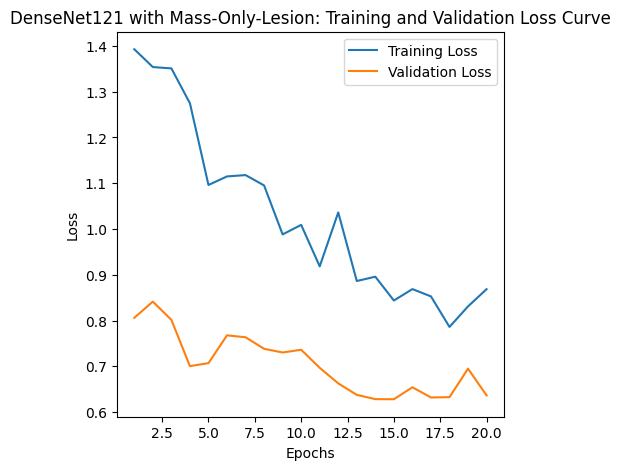

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_m.history, 'DenseNet121', 'Mass-Only-Lesion')

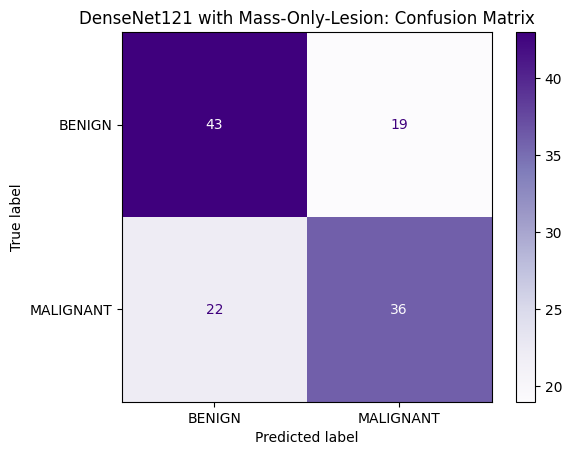

In [ ]:
plot_confusion_matrix(val_true_labels_m, preds_densenet121_m, 'DenseNet121', 'Mass-Only-Lesion')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_m = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_m, train_time_mobilenetv2_m, peak_memory_mobilenetv2_m = train_selected_model(mobilenetv2_model_m,
                                                                                          train_dataset_m,
                                                                                          val_dataset_m,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict_m)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 22s 598ms/step - auc: 0.4733 - loss: 0.7195 - precision: 0.4722 - recall: 0.2161 - val_auc: 0.5078 - val_loss: 0.7154 - val_precision: 0.5714 - val_recall: 0.2759
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 492ms/step - auc: 0.4892 - loss: 0.6942 - precision: 0.5143 - recall: 0.1525 - val_auc: 0.5611 - val_loss: 0.7043 - val_precision: 0.6250 - val_recall: 0.3448
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 396ms/step - auc: 0.5054 - loss: 0.6975 - precision: 0.5000 - recall: 0.2288 - val_auc: 0.5718 - val_loss: 0.6978 - val_precision: 0.6216 - val_recall: 0.3966
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 515ms/step - auc: 0.5403 - loss: 0.6868 - precision: 0.6000 - recall: 0.1907 - val_auc: 0.6106 - val_loss: 0.7118 - val_precision: 0.5593 - val_recall: 0.5690
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 504ms/step - auc: 0.5144 - loss: 0.7074 - precision: 0.5093 - recall: 0.4619 - val_auc: 0.5970 - val_loss:

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
_, preds_mobilenetv2_m, metrics_dict_mobilenetv2_m, infer_time_mobilenetv2_m = generate_predictions_and_evaluations(mobilenetv2_m, val_dataset_m, val_true_labels_m,
                                                                                                                    CLASSIFICATION_THRESHOLD)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 505ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - auc: 0.6682 - loss: 0.6494 - precision: 0.7500 - recall: 0.3103


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_m_results_df = generate_lesion_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_mobilenetv2_m,
    train_time=train_time_mobilenetv2_m,
    infer_time=infer_time_mobilenetv2_m,
    peak_memory=peak_memory_mobilenetv2_m
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_m_results_df)

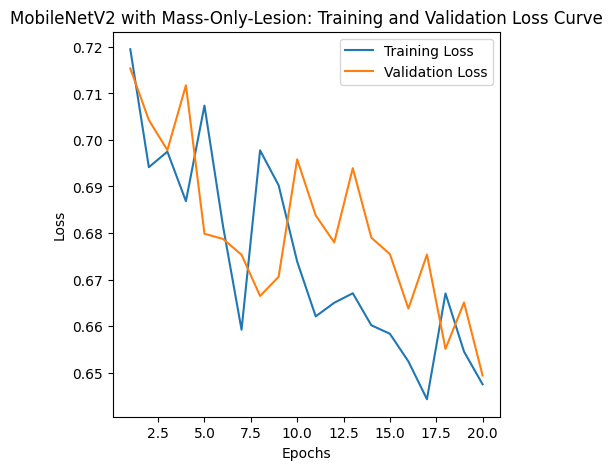

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_m.history, 'MobileNetV2', 'Mass-Only-Lesion')

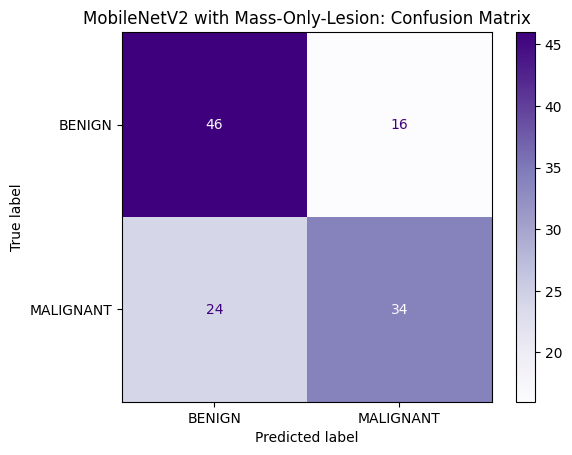

In [ ]:
plot_confusion_matrix(val_true_labels_m, preds_mobilenetv2_m, 'MobileNetV2', 'Mass-Only-Lesion')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_m = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_m, train_time_efficientnetb0_m, peak_memory_efficientnetb0_m = train_selected_model(efficientnetb0_model_m,
                                                                                                   train_dataset_m,
                                                                                                   val_dataset_m,
                                                                                                   EXPERIMENTAL_EPOCHS,
                                                                                                   early_stopping,
                                                                                                   class_weights_dict_m)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 27s 647ms/step - auc: 0.4941 - loss: 0.7106 - precision: 0.6429 - recall: 0.1144 - val_auc: 0.6270 - val_loss: 0.6802 - val_precision: 0.6500 - val_recall: 0.2241
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 482ms/step - auc: 0.5974 - loss: 0.6519 - precision: 0.7213 - recall: 0.1864 - val_auc: 0.6355 - val_loss: 0.6535 - val_precision: 0.7692 - val_recall: 0.1724
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 423ms/step - auc: 0.6788 - loss: 0.6230 - precision: 0.7576 - recall: 0.4237 - val_auc: 0.6462 - val_loss: 0.6499 - val_precision: 0.7727 - val_recall: 0.2931
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 408ms/step - auc: 0.6781 - loss: 0.6147 - precision: 0.7344 - recall: 0.3983 - val_auc: 0.6415 - val_loss: 0.6522 - val_precision: 0.7059 - val_recall: 0.4138
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 474ms/step - auc: 0.6449 - loss: 0.6075 - precision: 0.6897 - recall: 0.3390 - val_auc: 0.6471 - val_loss: 

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
_, preds_efficientnetb0_m, metrics_dict_efficientnetb0_m, infer_time_efficientnetb0_m = generate_predictions_and_evaluations(efficientnetb0_m, val_dataset_m,
                                                                                                                             val_true_labels_m,
                                                                                                                             CLASSIFICATION_THRESHOLD)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 832ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - auc: 0.7225 - loss: 0.6265 - precision: 0.8065 - recall: 0.4310


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_m_results_df = generate_lesion_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_efficientnetb0_m,
    train_time=train_time_efficientnetb0_m,
    infer_time=infer_time_efficientnetb0_m,
    peak_memory=peak_memory_efficientnetb0_m
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_m_results_df)

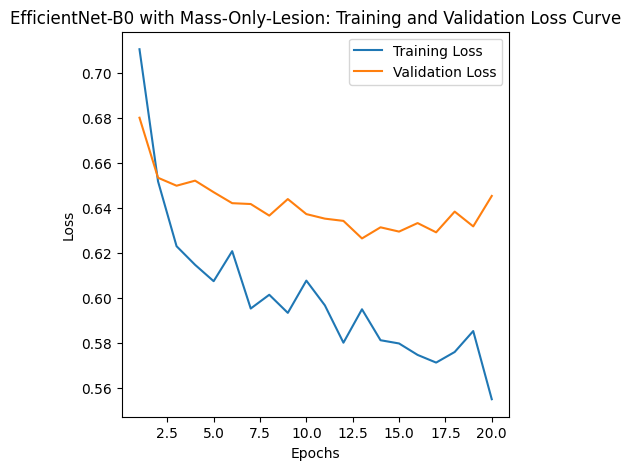

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_m.history, 'EfficientNet-B0', 'Mass-Only-Lesion')

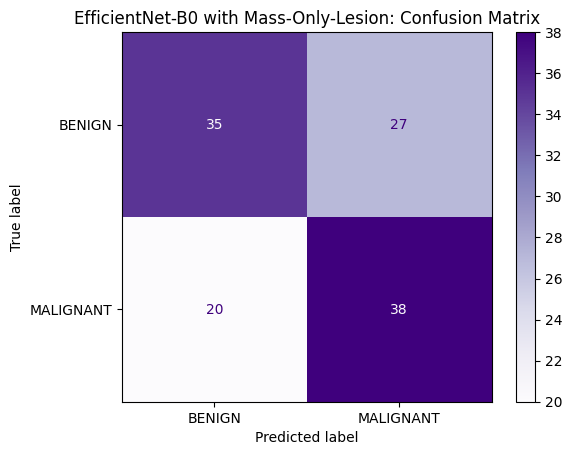

In [ ]:
plot_confusion_matrix(val_true_labels_m, preds_efficientnetb0_m, 'EfficientNet-B0', 'Mass-Only-Lesion')